# Proteomics Pathway Scoring in Kinase Inhibitor Response to KIX-119

As a bioinformatics scientist supporting a kinase inhibitor program, I use this synthetic phosphoproteomics notebook for pathway-level response analysis. The project identifier for this simulated study is `KIX119_SYNTH_PHOSPHO_001`.

## Biological Model

`KIX-119` is modeled as a selective upstream MAPK pathway inhibitor. I expect reduced ERK activation-loop phosphorylation, modest cell-cycle slowing through RB1-associated sites, and a compensatory PI3K survival response marked by increased `AKT_S473`. The synthetic panel includes 120 phosphosites distributed across MAPK, PI3K, DNA damage, and cell-cycle signaling.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 119
rng = np.random.default_rng(RANDOM_SEED)

control_reps = [f"KIX119_CTRL_{i}" for i in range(1, 4)]
treated_reps = [f"KIX119_TRT_{i}" for i in range(1, 4)]
pathway_order = ["MAPK", "PI3K", "DNA_damage", "Cell_cycle"]

target_pathway_deltas = {
    "MAPK": -1.45,
    "PI3K": 0.38,
    "DNA_damage": 0.12,
    "Cell_cycle": -0.52,
}

print(f"Project KIX119_SYNTH_PHOSPHO_001 uses seed {RANDOM_SEED}")
print(f"Replicates: {len(control_reps)} control, {len(treated_reps)} treated")

Project KIX119_SYNTH_PHOSPHO_001 uses seed 119
Replicates: 3 control, 3 treated


In [3]:
marker_rows = [
    {"phosphosite": "ERK1_T202_Y204", "pathway": "MAPK", "marker_note": "ERK activation loop readout"},
    {"phosphosite": "AKT_S473", "pathway": "PI3K", "marker_note": "PI3K survival arm readout"},
    {"phosphosite": "RB1_S807", "pathway": "Cell_cycle", "marker_note": "G1/S checkpoint readout"},
]

annotation_rows = list(marker_rows)
site_prefix = {
    "MAPK": "MAPK_NODE",
    "PI3K": "PI3K_NODE",
    "DNA_damage": "DDR_NODE",
    "Cell_cycle": "CC_NODE",
}

for pathway in pathway_order:
    existing_count = sum(row["pathway"] == pathway for row in annotation_rows)
    for idx in range(1, 30 - existing_count + 1):
        annotation_rows.append(
            {
                "phosphosite": f"{site_prefix[pathway]}_{idx:03d}",
                "pathway": pathway,
                "marker_note": "synthetic phosphosite",
            }
        )

annotation = pd.DataFrame(annotation_rows)
annotation["project_id"] = "KIX119_SYNTH_PHOSPHO_001"

site_baseline = rng.normal(loc=24.0, scale=1.1, size=len(annotation))
intensity = pd.DataFrame(index=annotation["phosphosite"], columns=control_reps + treated_reps, dtype=float)

for pathway in pathway_order:
    pathway_sites = annotation.loc[annotation["pathway"].eq(pathway), "phosphosite"].to_list()
    site_idx = annotation.index[annotation["pathway"].eq(pathway)].to_numpy()
    baselines = site_baseline[site_idx]

    control_noise = rng.normal(0, 0.08, size=(len(pathway_sites), len(control_reps)))
    control_noise -= control_noise.mean()
    treated_noise = rng.normal(0, 0.08, size=(len(pathway_sites), len(treated_reps)))
    treated_noise -= treated_noise.mean()

    intensity.loc[pathway_sites, control_reps] = baselines[:, None] + control_noise
    intensity.loc[pathway_sites, treated_reps] = baselines[:, None] + target_pathway_deltas[pathway] + treated_noise

print(f"phosphosite_intensity_matrix {intensity.shape[0]} sites x {intensity.shape[1]} replicates")
print(annotation["pathway"].value_counts().sort_index().to_string())
annotation.loc[
    annotation["phosphosite"].isin(["ERK1_T202_Y204", "AKT_S473", "RB1_S807"]),
    ["phosphosite", "pathway", "marker_note"],
]

phosphosite_intensity_matrix 120 sites x 6 replicates
pathway
Cell_cycle    30
DNA_damage    30
MAPK          30
PI3K          30


,phosphosite,pathway,marker_note
0,ERK1_T202_Y204,MAPK,ERK activation loop readout
1,AKT_S473,PI3K,PI3K survival arm readout
2,RB1_S807,Cell_cycle,G1/S checkpoint readout


## Normalization Strategy

I normalize each phosphosite to its own mean control intensity, producing log2 response values centered at zero for the untreated state. This keeps the pathway score interpretable as a condition-specific activity shift while retaining replicate-level variation.

In [4]:
control_mean = intensity[control_reps].mean(axis=1)
normalized = intensity.sub(control_mean, axis=0)

normalization_qc = pd.Series(
    {
        "mean_control_signal_after_normalization": normalized[control_reps].mean().mean(),
        "median_abs_control_signal": normalized[control_reps].abs().stack().median(),
        "largest_abs_treated_response": normalized[treated_reps].abs().max().max(),
    }
)
normalization_qc.round(3)

mean_control_signal_after_normalization   -0.000
median_abs_control_signal                  0.041
largest_abs_treated_response               1.653
dtype: float64

In [5]:
def score_pathway_activity(normalized_matrix, annotation_table, control_columns, treated_columns):
    """Average normalized phosphosite response by pathway and condition."""
    rows = []
    site_to_pathway = annotation_table.set_index("phosphosite")["pathway"]

    for pathway in pathway_order:
        pathway_sites = site_to_pathway.index[site_to_pathway.eq(pathway)]
        control_activity = normalized_matrix.loc[pathway_sites, control_columns].to_numpy().mean()
        treated_activity = normalized_matrix.loc[pathway_sites, treated_columns].to_numpy().mean()
        rows.append(
            {
                "pathway": pathway,
                "control_activity": control_activity,
                "treated_activity": treated_activity,
                "activity_delta": treated_activity - control_activity,
            }
        )

    return pd.DataFrame(rows).set_index("pathway")

pathway_activity = score_pathway_activity(normalized, annotation, control_reps, treated_reps).round(2)

print(f"MAPK_activity_delta {pathway_activity.loc['MAPK', 'activity_delta']:.2f}")
print(f"PI3K_activity_delta {pathway_activity.loc['PI3K', 'activity_delta']:.2f}")
pathway_activity

MAPK_activity_delta -1.45
PI3K_activity_delta 0.38


,control_activity,treated_activity,activity_delta
pathway,,,
MAPK,-0.0,-1.45,-1.45
PI3K,-0.0,0.38,0.38
DNA_damage,-0.0,0.12,0.12
Cell_cycle,0.0,-0.52,-0.52


heatmap_placeholder KIX119_pathway_activity_heatmap: MAPK suppression is the dominant blue signal; PI3K activation is the compensatory amber signal


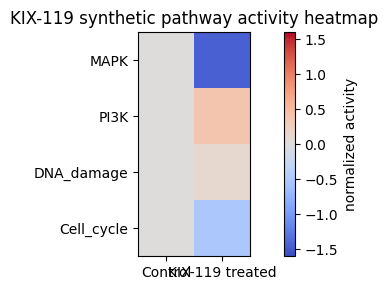

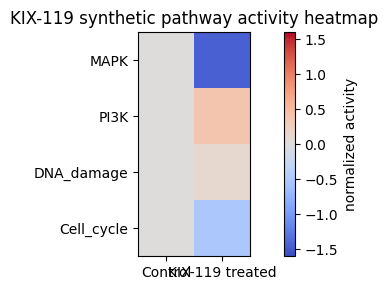

In [6]:
heatmap_values = pathway_activity.loc[pathway_order, ["control_activity", "treated_activity"]]

fig, ax = plt.subplots(figsize=(7, 3))
im = ax.imshow(heatmap_values.to_numpy(), cmap="coolwarm", vmin=-1.6, vmax=1.6)
ax.set_xticks(range(2), labels=["Control", "KIX-119 treated"])
ax.set_yticks(range(len(pathway_order)), labels=pathway_order)
ax.set_title("KIX-119 synthetic pathway activity heatmap")
fig.colorbar(im, ax=ax, label="normalized activity")
fig.tight_layout()

print(
    "heatmap_placeholder KIX119_pathway_activity_heatmap: "
    "MAPK suppression is the dominant blue signal; PI3K activation is the compensatory amber signal"
)
fig

In [7]:
marker_ids = ["ERK1_T202_Y204", "AKT_S473", "RB1_S807"]
marker_summary = pd.DataFrame(index=marker_ids)
marker_summary["pathway"] = annotation.set_index("phosphosite").loc[marker_ids, "pathway"]
marker_summary["mean_control"] = normalized.loc[marker_ids, control_reps].mean(axis=1)
marker_summary["mean_treated"] = normalized.loc[marker_ids, treated_reps].mean(axis=1)
marker_summary["marker_delta"] = marker_summary["mean_treated"] - marker_summary["mean_control"]
marker_summary.round(2)

,pathway,mean_control,mean_treated,marker_delta
ERK1_T202_Y204,MAPK,0.0,-1.48,-1.48
AKT_S473,PI3K,0.0,0.35,0.35
RB1_S807,Cell_cycle,0.0,-0.52,-0.52


## Interpretation

The synthetic pathway activity table supports the expected pharmacology of `KIX-119`: `MAPK_activity_delta -1.45` indicates strong on-target MAPK suppression, led by reduced `ERK1_T202_Y204` signal. The same run reports `PI3K_activity_delta 0.38`, consistent with compensatory PI3K activation through the survival marker `AKT_S473`.

The cell-cycle signal is lower after treatment, including reduced `RB1_S807`, while DNA damage signaling is only mildly increased. KIX-119 produces a clear MAPK inhibition signature with a smaller adaptive PI3K response, summarized by `score_pathway_activity`.